In [70]:
## Question 1 a)

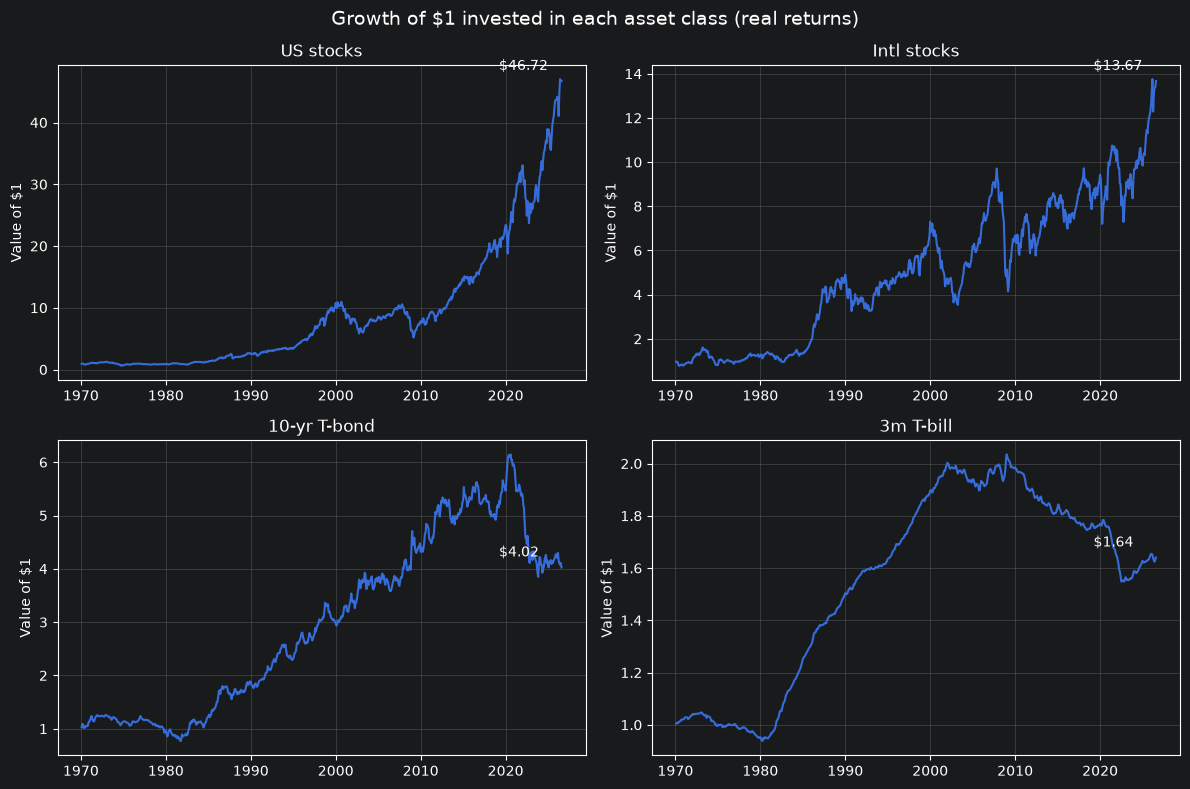

,Real mean annual return,Real annual std dev
real_us_stocks_return,8.43,16.88
real_intl_stocks_return,6.58,20.09
real_10yr_return,3.07,9.90
real_3mnth_return,0.94,2.91


In [73]:
from mqf_hw1.data import load_data
import pandas as pd
import matplotlib.pyplot as plt

df = load_data()
df["real_us_stocks_return"] = ((1+df["us_stocks"])/(1+df["cpi_inflation"]))-1
df["real_intl_stocks_return"] = ((1+df["intl_stocks"])/(1+df["cpi_inflation"]))-1
df["real_10yr_return"] = ((1+df["10-yr T-bond"])/(1+df["cpi_inflation"]))-1
df["real_3mnth_return"] = ((1+df["3m T-bill"])/(1+df["cpi_inflation"]))-1
df.head()

def real_mean_annual_growth(df, column, date_col="date"):
    growth = 1 + df[column]
    yearly = growth.groupby(df[date_col].dt.year).prod()
    return yearly.mean() - 1


df["date"] = pd.to_datetime(df["date"])

def real_mean_annual_growth(df, column, date_col="date"):
    growth = 1 + df[column]
    yearly = growth.groupby(df[date_col].dt.year).prod()
    return yearly.mean() - 1

assets = [
    "real_us_stocks_return",
    "real_intl_stocks_return",
    "real_10yr_return",
    "real_3mnth_return",
]

def real_annual_std(df, column, date_col="date"):
    growth = 1 + df[column]
    yearly = growth.groupby(df[date_col].dt.year).prod()
    return (yearly - 1).std()

df_full = df[df["date"].dt.year < 2026]   # I am dropping it because

mean_results = {a: real_mean_annual_growth(df_full, a) for a in assets}
std_results = {a: real_annual_std(df_full, a) for a in assets}

summary = pd.DataFrame({
    "Real mean annual return": pd.Series(mean_results),
    "Real annual std dev": pd.Series(std_results),
})

assets = [
    "real_us_stocks_return",
    "real_intl_stocks_return",
    "real_10yr_return",
    "real_3mnth_return",
]
labels = ["US stocks", "Intl stocks", "10-yr T-bond", "3m T-bill"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, label in zip(axes.flat, assets, labels):
    growth = (1 + df[col]).cumprod()          # value of $1 over time
    ax.plot(df["date"], growth)
    ax.set_title(label)
    ax.set_ylabel("Value of $1")
    ax.grid(True, alpha=0.3)
    ax.annotate(f"${growth.iloc[-1]:.2f}",
                xy=(df["date"].iloc[-1], growth.iloc[-1]),
                xytext=(-45, 8), textcoords="offset points")

fig.suptitle("Growth of $1 invested in each asset class (real returns)", fontsize=14)
fig.tight_layout()
fig.savefig("growth_of_1_dollar.png", dpi=200)
plt.show()


(summary * 100).round(2)

##A  short paragraph of interpretation:  As expected US equities significantly outperformed Fixed Income. Bills are a textbook definition of a risk free asset so the minimal returns hide behind minimal risk. 10yr Treasuries are also underperforming stocks given the absence of capital gains



Question 1 b)

          date  us_stocks  intl_stocks  10-yr T-bond  3m T-bill  \
0   1970-01-31  -0.075398    -0.021370      0.028827   0.007158   
1   1970-02-28   0.059521    -0.013008      0.067886   0.007986   
2   1970-03-31   0.002806    -0.000932     -0.000269   0.007078   
3   1970-04-30  -0.088831    -0.105223     -0.050871   0.005494   
4   1970-05-31  -0.054689    -0.074294     -0.006522   0.006237   
..         ...        ...          ...           ...        ...   
674 2026-03-31  -0.049795    -0.097383     -0.023072   0.003086   
675 2026-04-30   0.104927     0.073918     -0.004468   0.003070   
676 2026-05-31   0.052633     0.028097     -0.000273   0.003103   
677 2026-06-30  -0.009523    -0.001711      0.004417   0.002788   
678 2026-07-31  -0.000635     0.020629     -0.020556   0.003335   

     cpi_inflation  real_us_stocks_return  real_intl_stocks_return  \
0         0.002653              -0.077844                -0.023959   
1         0.005291               0.053945              